# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata
nlp = spacy.load("es_core_news_sm")
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import community.community_louvain as community_louvain
import matplotlib.patches as mpatches

# **Organizaciones**

In [ ]:
carpeta = 'C:/Users/Desktop/caso_05'
contenido_archivos = []
for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt') and 'Rueda de prensa' not in archivo:
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido_archivos.append(f.read())
contenido_combinado= '\n'.join(contenido_archivos)

len(contenido_combinado)
texto=contenido_combinado

In [ ]:
# Normalización
def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

# buscar: resguardo / asociacion / consejo en el texto sin depurar.
patron_organizacion = re.compile(
    r'\b(?:'
    r'resg(?:ua|u)rdo'
    r'|asociacion'
    r'|consejo'
    r')\s+'
    r'(?:indigena\s+)?'
    r'(?:[a-z]+(?:\s+[a-z]+){0,6})',
    re.IGNORECASE
)

def extraer_organizaciones_indigenas(texto):
    texto = normalizar(texto)
    return [m.group().strip() for m in patron_organizacion.finditer(texto)]

extraer_organizaciones_indigenas(texto)

['asociacion de mujeres del norte del cauca',
 'asociacion de mujeres afrodescendientes del norte del cauca',
 'asociacion de mujeres es muy importante este espacio',
 'consejo regional  indigena del cauca',
 'consejo regional indigena del cauca',
 'resguardo indigena de honduras',
 'consejo de guerra para enjuiciar al guerrillero de',
 'asociacion que se encuentra en el sur del',
 'consejo regional indigena del cauca cric',
 'consejo regional indigena del cauca',
 'asociacion de consejos comunitarios del sur del valle',
 'asociacion de consejos comunitarios del norte del cauca',
 'consejo comunitario sanjon de garrapatero',
 'asociacion de consejos comunitarios del norte del cauca',
 'asociacion de mujeres afrodescendientes del norte del cauca',
 'consejo comunitario de la toma',
 'resguardo indigena de la guada san antonio',
 'resguardo indigena cahuequina las mercedes',
 'resguardo paez de huellas',
 'resguardo indigena de pueblo nuevo',
 'resguardo indigena de san lorenzo de caldon

In [ ]:
## Guardamos el nombre de la organización, el municipio donde se localiza y el código del municipio. Esta información se obtuvo mediante una búsqueda individual
# de cada una de las organizaciones a través de su página web.
data = [
    ("Resguardo Indígena de Honduras", "Morales", 19473),
    ("Resguardo Indígena de La Aguada San Antonio", "Caldono", 19137),
    ("Resguardo Indígena Las Mercedes", "Caldono", 19137),
    ("Resguardo Indígena de Huellas", "Caloto", 19142),
    ("Resguardo Indígena de Huellas", "Jambaló", 19364),
    ("Resguardo Indígena de Pueblo Nuevo", "Caldono", 19137),
    ("Resguardo Indígena Las Delicias", "Buenos Aires", 19110),
    ("Resguardo Indígena Kwe'sx Yu Kiwe", "Florida", 76275),
    ("Resguardo Indígena Las Delicias", "Buenos Aires", 19110),
    ("Resguardo Indígena de Pioyá", "Caldono", 19137),
    ("Resguardo Indígena de San Francisco", "Toribío", 19821),

    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Buenos Aires", 19110),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Suárez", 19780),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Santander de Quilichao", 19698),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Jambaló", 19364),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Caloto", 19142),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Toribío", 19821),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Guachené", 19300),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Villa Rica", 19845),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Puerto Tejada", 19573),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Miranda", 19455),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Corinto", 19212),
    ("Asociación de Mujeres Afrodescendientes del Norte del Cauca", "Padilla", 19513),
    ("Asociación de Cabildos Indígenas de Toribío, Tacueyó y San Francisco", "Toribio", 19821),
    ("Consejo Comunitario de la Toma", "Suárez", 19780),
    ("Consejo Comunitario Cuenca del Río Cauca y Microcuenca del Río Tétama Zamamorrero", "Santander de Quilichao", 19698),
    ("Consejo Comunitario Cuenca del Río Cauca y Microcuenca del Río Tétama Zamamorrero", "Buenos Aires", 19110),

    ("Asociación de Mujeres Tejedoras de Futuro de Timba", "Buenos Aires", 19110),
    ("Consejo Comunitario Cuenca del Río Timba", "Santander de Quilichao", 19698),
    ("Consejo Comunitario Cuenca del Río Timba", "Buenos Aires", 19110),
    ("Consejo Comunitario de Comunidades Negras Cerro Teta", "Buenos Aires", 19110),
    ("Consejo Comunitario Cuenca del Río Agua Blanca", "Buenos Aires", 19110),
    ("Consejo Comunitario Zanjón de Garrapatero", "Santander de Quilichao", 19698),
    ("Consejo Comunitario de la Comunidad Negra de Pilamó", "Guachené", 19300),
    ("Consejo Comunitario Brisas del Río Palo", "Guachené", 19300),
    ("Asociación de Cabildos Indígenas de Toribío, Tacueyó y San Francisco", 19821)
]
df = pd.DataFrame(
    data,
    columns=["organizacion", "municipio", "codigo_dane"])

In [ ]:
import geopandas as gpd
## Cargamos el shape file del mapa de municipios y departamentos de Colombia. Se obtiene de https://www.dane.gov.co/files/geoportal-provisional/
ruta_shape = "C:/Users/Desktop/Casos_JEP/material_adicional/mapa/MGN_MPIO_POLITICO.shp"
gdf_mun = gpd.read_file(ruta_shape)
gdf_mun.columns

df["codigo_dane"] = df["codigo_dane"].astype(str)
gdf_mun["MPIO_CDPMP"] = gdf_mun["MPIO_CDPMP"].astype(str)
gdf_mun = gdf_mun[gdf_mun["DPTO_CNMBR"].isin(["CAUCA", "VALLE DEL CAUCA"]) ##Solo ubicamos municipios en estos dos departamentos
]

gdf_org = gdf_mun.merge(df,left_on="MPIO_CDPMP",right_on="codigo_dane",how="left")
conteo = (df.groupby("codigo_dane").size().reset_index(name="n_org"))
conteo["codigo_dane"] = (pd.to_numeric(conteo["codigo_dane"], errors="coerce").dropna().astype(int).astype(str).str.zfill(5))


gdf_org = gdf_mun.merge(conteo,left_on="MPIO_CDPMP",right_on="codigo_dane",how="left")
gdf_org["n_org"] = gdf_org["n_org"].fillna(0)

In [ ]:
gdf_org[["MPIO_CNMBR", "n_org"]].sort_values("n_org", ascending=False)

,MPIO_CNMBR,n_org
5,BUENOS AIRES,8.0
7,CALDONO,4.0
27,SANTANDER DE QUILICHAO,4.0
11,GUACHENÉ,3.0
34,TORIBÍO,3.0
...,...,...
79,LA CUMBRE,0.0
80,JAMUNDÍ,0.0
81,BOLÍVAR,0.0
82,DAGUA,0.0


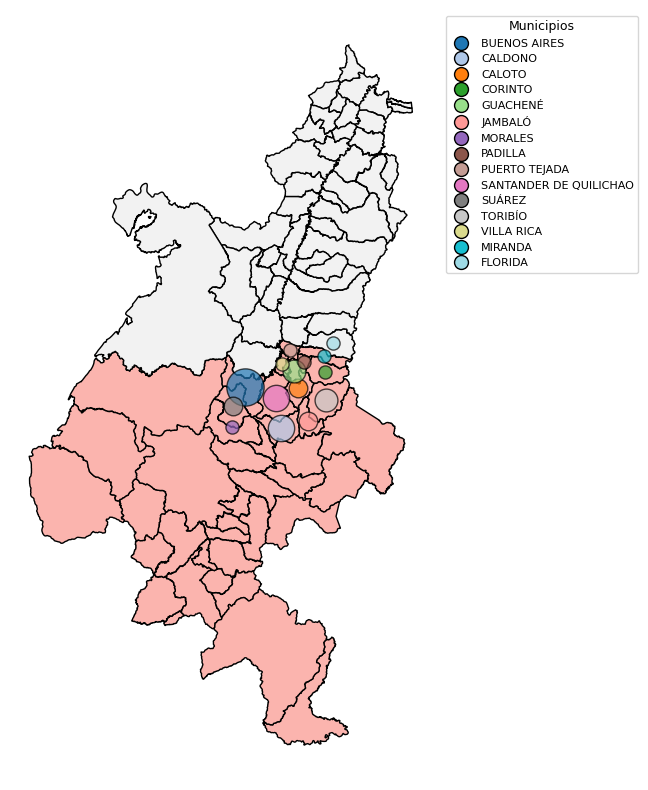

In [ ]:
###Gráfico conforme al número de organizaciones por municipio.

gdf_mapa = gdf_org.to_crs(epsg=3116)
gdf_mapa["centroid"] = gdf_mapa.geometry.centroid
gdf_mapa["DPTO_CNMBR"] = gdf_mapa["DPTO_CNMBR"].str.upper()
colores_depto = {
    "CAUCA": "#e0e0e0",
    "VALLE DEL CAUCA": "#cfcfcf"}

gdf_mapa["color_depto"] = gdf_mapa["DPTO_CNMBR"].map(colores_depto)
gdf_mapa["mun_circulo"] = gdf_mapa.loc[gdf_mapa["n_org"] > 0, "MPIO_CNMBR"]

municipios = gdf_mapa.loc[gdf_mapa["n_org"] > 0, "MPIO_CNMBR"].unique()
colors = cm.tab20(np.linspace(0, 1, len(municipios)))

color_dict = dict(zip(municipios, colors))

gdf_mapa = gdf_org.to_crs(epsg=3116)
gdf_mapa["centroid"] = gdf_mapa.geometry.centroid

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_mapa.plot( ax=ax, column="DPTO_CNMBR", categorical=True, legend=True, cmap="Pastel1", edgecolor="black")

municipios = gdf_mapa.loc[gdf_mapa["n_org"] > 0, "MPIO_CNMBR"].unique()
colors = cm.tab20(np.linspace(0, 1, len(municipios)))
color_dict = dict(zip(municipios, colors))

for mun in municipios:
    subset = gdf_mapa[gdf_mapa["MPIO_CNMBR"] == mun]

    ax.scatter( subset.centroid.x, subset.centroid.y, s=subset["n_org"] * 90, color=color_dict[mun],
        alpha=0.7, edgecolors="black",)

legend_elements = [Line2D(  [0], [0], marker="o", color="w", label=mun, markerfacecolor=color_dict[mun], markeredgecolor="black",   markersize=10)
    for mun in municipios]

ax.legend(  handles=legend_elements,  title="Municipios",  bbox_to_anchor=(1.02, 1),  loc="upper left",
    fontsize=8,  title_fontsize=9,  frameon=True)
ax.axis("off")
plt.show()


# **Limpieza de texto**

In [ ]:
#FUNCIONES DE LIMPIEZA DE TEXTO

def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []

    # Generar todos los pares (w_i, w_j) donde 1 ≤ j - i ≤ k + 1
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado


In [ ]:
#lematizar palabras reconocidas:
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

palabras = texto.split()
palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
texto_lematizado = ' '.join(palabras_lematizadas) #Obtenemos el texto nuevamente.

#Eliminar palabras de uno o dos caracteres:
texto_filtrado=eliminar_palabras_cortas(texto_lematizado)
texto_filtrado

##Tokenizar
tokens = nltk.word_tokenize(texto_filtrado, language="spanish")
texto_para_udpipe = " ".join(tokens)

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# Lematizacion con spacy
nlp = spacy.load("es_core_news_md", disable=["parser","ner"])
excepciones = {"soldado", "voluntario"}

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser","ner"])
        for token_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if token_original.lower() in excepciones:
                lemas.append(token_original.lower())
            else:
                lemas.append(token_spacy.lemma_)

    return lemas
lemas = lematizar_en_bloques(tokens, bloque_size=10000)

# reconstruir texto:
texto_lemas = " ".join(lemas)

# **CREAR DICCIONARIO**

In [ ]:
# verificar si existen las palabras a través de un diccionario:
import re
from spellchecker import SpellChecker
spell = SpellChecker(language="es")

def limpiar_y_revisar(lemas):
    limpios = []
    typos = []

    for lema in lemas:
        palabra = lema.lower().strip()
        palabra = re.sub(r"[0-9]", "", palabra)
        if not palabra:
            continue
        if len(palabra) <= 2:
            continue
        if palabra in spell:
            limpios.append(palabra)
        else:
            typos.append(palabra)

    return limpios, typos

lemas_limpios, posibles_typos = limpiar_y_revisar(lemas)

print("Lemas válidos:", len(lemas_limpios))
print("Posibles typos:", len(posibles_typos))

Lemas válidos: 57271
Posibles typos: 5625


In [ ]:
# Primera depuración de las palabras identificadas como typo
print(sys.getdefaultencoding())

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()
PromptInicio = (
    "Utilizando la lista de palabras proporcionada a continuación, "
    "extrae únicamente las palabras que NO pertenecen al idioma español "
    "y que parecen errores o ruido de subtítulos automáticos. "
    "No marques como errores las palabras correctas en español, "
    "aunque sean poco frecuentes.\n\n[Inicio lista]\n"
)
PromptFinal = "\n[Fin lista]\n\nResponde únicamente con una lista de los posibles errores."

def revisar_con_gpt(palabras, bloque_size=500):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio + lista_str + PromptFinal

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente lingüístico experto en español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    return resultados

errores_detectados = revisar_con_gpt(posibles_typos, bloque_size=300)
ruta_errores = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_errores, "w", encoding="utf-8") as f:
    for bloque in errores_detectados:
        f.write(bloque + "\n")

In [ ]:
# Cargar el archivo depurado previamente para depurarlo
ruta_archivo = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

lineas_limpias = [linea.lstrip("- ").strip() for linea in lineas]
client = OpenAI()

# Prompt para corrección y lematización
PromptInicio_corr = (
    "A partir de la lista de palabras proporcionada a continuación, "
    "propón una corrección para cada palabra y redúcela a su raíz más pequeña (lema). "
    "Si la palabra no tiene significado o no se puede corregir, responde con 'NA'.\n\n"
    "[Inicio lista]\n")

PromptFinal_corr = (
    "\n[Fin lista]\n\n"
    "Responde únicamente en el formato:\n"
    "palabra_original - correccion")

def corregir_y_lematizar(palabras, bloque_size=300):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio_corr + lista_str + PromptFinal_corr

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente experto en lingüística y lematización del español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    # Unir todos los bloques 
    texto_resultado = "\n".join(resultados)
    pares = [line.strip() for line in texto_resultado.splitlines() if "-" in line]
    data = [line.split("-", 1) for line in pares]
    df = pd.DataFrame(data, columns=["original", "correccion"])
    df["original"] = df["original"].str.strip()
    df["correccion"] = df["correccion"].str.strip()

    return df
df_correcciones = corregir_y_lematizar(lineas_limpias, bloque_size=100)

# Guardar en un archivo
df_correcciones.to_csv("correcciones.csv", index=False, encoding="utf-8")

ruta = "C:/Users/Downloads/correcciones.txt" 
with open(ruta, "w", encoding="utf-8") as f:
    for _, row in df_correcciones.iterrows():
        f.write(f"{row['original']} : {row['correccion']}\n")


In [ ]:
# Remover palabras repetidas y guardar el archivo final:
ruta_entrada = ruta
ruta_salida = "C:/Users/Desktop/Casos_JEP/salida_05.txt"
with open(ruta_entrada, "r", encoding="utf-8") as f:
    lineas = f.readlines()
unicas = list(dict.fromkeys(lineas))
with open(ruta_salida, "w", encoding="utf-8") as f:
    f.writelines(unicas)

# **Limpieza y depuración de datos**

In [ ]:
# Depuración
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# -------------------- Cargar lematizacion anterior -----------------------------------------------
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_05.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

texto_lemas_dicc = []
for palabra in lemas:
    lema = lematizaciones2.get(palabra)
    if lema is None:
        texto_lemas_dicc.append(palabra)
    elif lema != "NA":
        texto_lemas_dicc.append(lema)

texto_final = " ".join(texto_lemas_dicc)
with open("texto_final_dicc.txt", "w", encoding="utf-8") as f:
    f.write(texto_final)

# ------------------------ Stopwords -------------------------------------------------
stop_words = set(stopwords.words('spanish'))
archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))


ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"

with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ----------------------- Limpiar, lematizar y filtrar ------------------------------------------
texto_final_limpio = limpiar_texto(texto_final)
palabras = texto_final_limpio.split()

palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
texto_lema = " ".join(palabras_lematizadas)

palabras = texto_lema.split()
palabras_filtradas = [p for p in palabras if p not in filtradas]
texto_final = " ".join(palabras_filtradas)

In [ ]:
##eliminar términos con frecuencia de 1:
texto_sin_stopwords = quitar_stopwords(texto_final) #remover stopwords
tokens = word_tokenize(texto_sin_stopwords)
frec = Counter(tokens)
tokens_filtrados = [t for t in tokens if frec[t] > 1]
texto_sin_stopwords = " ".join(tokens_filtrados)

##Generar skipgramas
skipgramas = generar_skipgramas(texto_sin_stopwords, 2, 2)
##eliminar bucles:
skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
conteo = Counter(skipgramas_sin_bucles)
skipgramas = [b for b, f in conteo.items()
if f > 1
    for _ in range(f)]

In [ ]:
#Guardar el texto sin stopwords para LDA:
ruta_text = r"C:/Users/Desktop/Casos_JEP/textos_depurados_final/texto_sin_stopwords_5.txt"
with open(ruta_text, "w", encoding="utf-8") as f:
    f.write(texto_sin_stopwords)

In [ ]:
from collections import Counter
skipgramas_contar = [' '.join(bigram) for bigram in skipgramas]
skipgramas_cuantos = Counter(skipgramas_contar )
top_10 = skipgramas_cuantos.most_common(10)
top_10


[('norte cauca', 120),
 ('violencia sexual', 99),
 ('valle cauca', 98),
 ('sur valle', 85),
 ('departamento cauca', 80),
 ('cauca valle', 73),
 ('pueblo indigena', 69),
 ('comunidad indigena', 66),
 ('autoridad indigena', 64),
 ('jurisdiccion especial', 63)]

In [ ]:
palabras_a_eliminar = ['yo', 'el']
patron = r'\b(?:' + '|'.join(palabras_a_eliminar) + r')\b'

# Limpieza
skipgramas_limpio = []
for w1, w2 in skipgramas:
    nuevo_w1 = re.sub(patron, '', w1).strip()
    nuevo_w2 = re.sub(patron, '', w2).strip()
    nuevo_w1 = ' '.join(nuevo_w1.split())
    nuevo_w2 = ' '.join(nuevo_w2.split())
    skipgramas_limpio.append((nuevo_w1, nuevo_w2))

In [ ]:
from collections import Counter
skipgramas_contar = [' '.join(bigram) for bigram in skipgramas_limpio]
skipgramas_cuantos = Counter(skipgramas_contar )
top_10 = skipgramas_cuantos.most_common(10)
top_10

[('norte cauca', 120),
 ('violencia sexual', 99),
 ('valle cauca', 98),
 ('sur valle', 85),
 ('departamento cauca', 80),
 ('cauca valle', 73),
 ('pueblo indigena', 69),
 ('comunidad indigena', 66),
 ('autoridad indigena', 64),
 ('jurisdiccion especial', 63)]

# **ANÁLISIS DESCRIPTIVO**

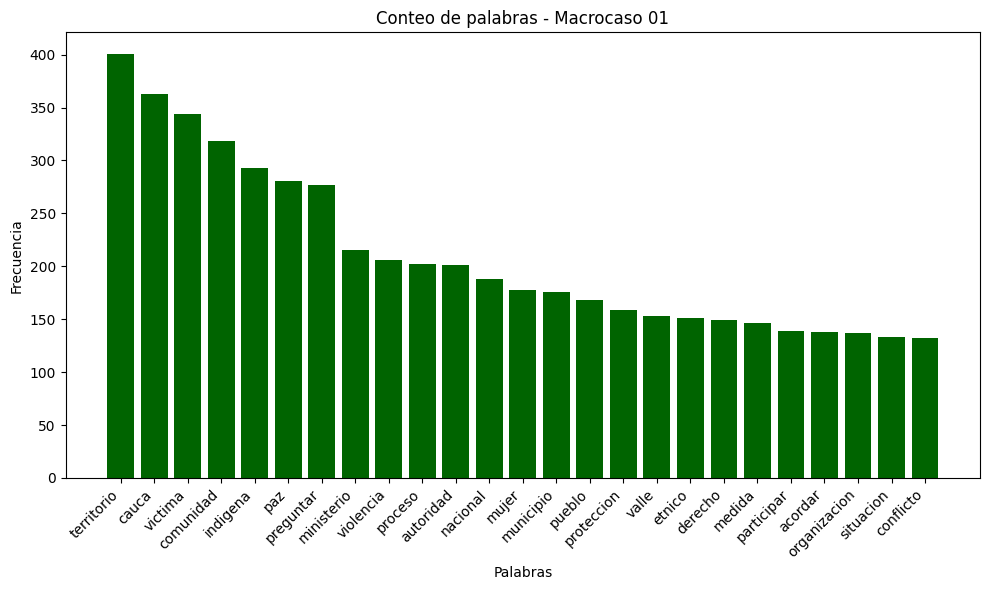

In [ ]:
tokens = nltk.word_tokenize(texto_sin_stopwords, language="spanish")
frecuencia_palabras = FreqDist(tokens)
palabras_repetidas = frecuencia_palabras.most_common(25)
palabras, frecuencias = zip(*palabras_repetidas)
plt.figure(figsize=(10, 6))
plt.bar(palabras, frecuencias, color="darkgreen")
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.title('Conteo de palabras - Macrocaso 01')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
frecuencia_palabras = FreqDist(tokens)
palabras_repetidas = frecuencia_palabras.most_common(10)
tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
print(tabla_frecuencias)

      Palabra  Frecuencia
0  territorio         401
1       cauca         363
2     victima         344
3   comunidad         318
4    indigena         293
5         paz         281
6   preguntar         277
7  ministerio         215
8   violencia         206
9     proceso         202


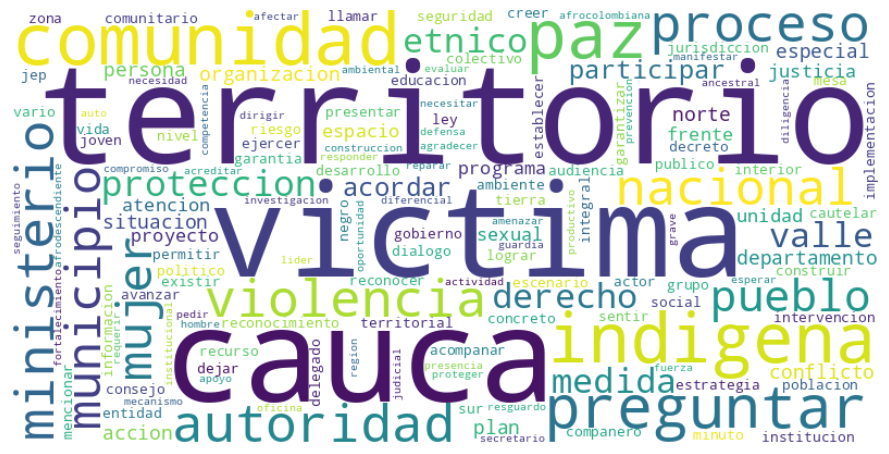

In [ ]:
# Crear distribución de frecuencia
frecuencia_palabras = FreqDist(tokens)
nube = WordCloud(width=800, height=400,
                 background_color='white',
                 #colormap='Dark2',
                 max_words=150).generate_from_frequencies(frecuencia_palabras)


plt.figure(figsize=(9, 5))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")

# Normalizar el léxico ------
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

def limpiar_palabra(p):
    if pd.isna(p):
        return ""
    p = unidecode(str(p).lower().strip())
    p = re.sub(r'[^a-zñáéíóúü\s]', '', p)
    p = re.sub(r'\s+', ' ', p)
    return p
lexico['Palabra'] = lexico['Palabra'].apply(limpiar_palabra)

columnas_emociones = ['Positive','Negative','Anger','Anticipation',
    'Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')

tokens = [limpiar_palabra(t) for t in word_tokenize(texto_sin_stopwords)]

conteo = Counter({emo: 0 for emo in columnas_emociones})

for token in tokens:
    if token in emociones:
        for emo, valor in emociones[token].items():
            conteo[emo] += valor

df_emociones = pd.DataFrame([conteo])
df_emociones.insert(0, 'Texto', 'audiencias')

# Traducir
traducciones = { 'Positive': 'Positivo', 'Negative': 'Negativo', 'Anger': 'Ira', 'Anticipation': 'Anticipación',
    'Disgust': 'Disgusto', 'Fear': 'Miedo', 'Joy': 'Alegría', 'Sadness': 'Tristeza', 'Surprise': 'Sorpresa',
    'Trust': 'Confianza'}

df_emociones = df_emociones.rename(columns=traducciones)
print(df_emociones)

        Texto  Positivo  Negativo   Ira  Anticipación  Disgusto  Miedo  \
0  audiencias      6094      2656  1552          2244       678   2136   

   Alegría  Tristeza  Sorpresa  Confianza  
0     1534      1695       718       3912  


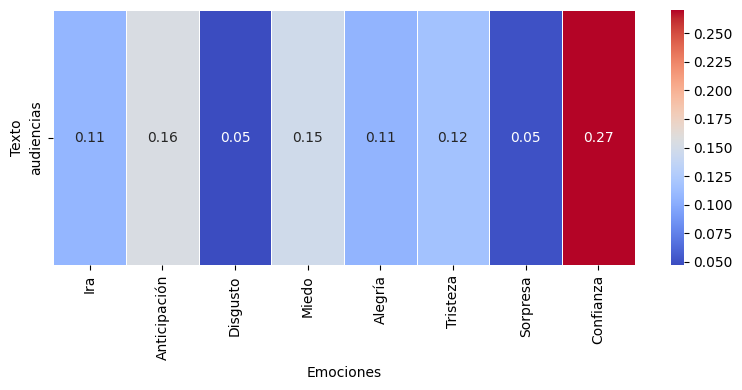

In [ ]:
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(8, 4))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Texto')
plt.tight_layout()
plt.show()


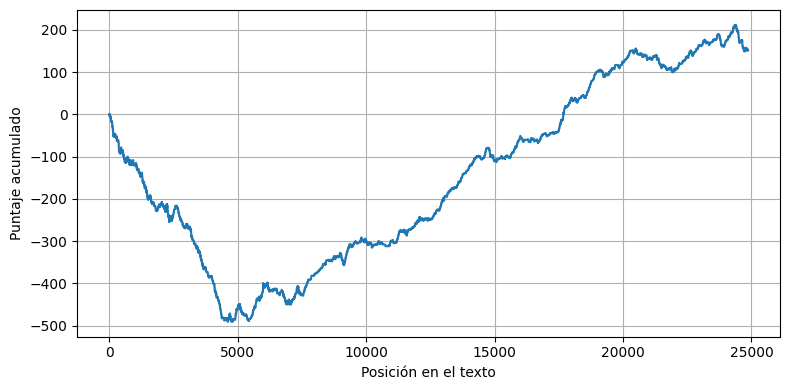

In [ ]:
#Sentimiento acumulado total:
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()

afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))
tokens = [unidecode(t.lower().strip())
    for t in word_tokenize(texto_sin_stopwords)]
puntajes = [afinn_dict.get(token, 0)
    for token in tokens]

df = pd.DataFrame({"palabra": tokens,"puntaje": puntajes})
df["sentimiento_acumulado"] = df["puntaje"].cumsum()
plt.figure(figsize=(8,4))
plt.plot(df.index, df["sentimiento_acumulado"])
plt.xlabel("Posición en el texto")
plt.ylabel("Puntaje acumulado")
plt.grid(True)
plt.tight_layout()
plt.show()

# **RED BASICA**

In [ ]:
# CREAR EL GRAFO NO DIRIGIDO
G = nx.Graph()
# Agregar nodos y aristas al grafo
for palabra1, palabra2 in skipgramas_limpio:
    G.add_edge(palabra1, palabra2)

nodo22 = list(G.edges())
len(nodo22)
print("Nodos en el grafo:", len(G.nodes))

Nodos en el grafo: 1516


In [ ]:
# Componentes conexas:
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
componente_gigante = componentes[0]
G_gigante = G.subgraph(componente_gigante).copy()

print("Nodos en componente gigante:", G_gigante.number_of_nodes())
print("Aristas en componente gigante:", G_gigante.number_of_edges())

Nodos en componente gigante: 1506
Aristas en componente gigante: 8974


In [ ]:
A = nx.to_pandas_adjacency(G_gigante, dtype=int)
#Metricas
A = nx.to_pandas_adjacency(G_gigante, dtype=int)
n = G_gigante.number_of_nodes()
m = G_gigante.number_of_edges()

grado_medio = np.mean([d for _, d in G_gigante.degree()])
grado_max = max(dict(G_gigante.degree()).values())
densidad = nx.density(G_gigante)

diametro = nx.diameter(G_gigante)
long_camino_prom = nx.average_shortest_path_length(G_gigante)

transitividad = nx.transitivity(G_gigante)
asortatividad = nx.degree_assortativity_coefficient(G_gigante)


In [ ]:
resumen = pd.DataFrame({
    "Métrica": [ "Número de nodos","Número de aristas","Grado medio","Grado máximo","Densidad",
        "Diámetro","Longitud media del camino","Transitividad","Asortatividad"],
    "Valor": [n,m, grado_medio,grado_max,densidad,diametro,long_camino_prom,transitividad,asortatividad]})
resumen


,Métrica,Valor
0,Número de nodos,1506.000000
1,Número de aristas,8974.000000
2,Grado medio,11.917663
3,Grado máximo,328.000000
4,Densidad,0.007919
5,Diámetro,7.000000
6,Longitud media del camino,3.072348
7,Transitividad,0.172302
8,Asortatividad,-0.148089


In [ ]:
# Calcular grado de cada nodo
grados = dict(G_gigante.degree())
df_grados = (
    pd.DataFrame(grados.items(), columns=["termino", "grado"])
    .sort_values("grado", ascending=False)
    .reset_index(drop=True))
top_grado = df_grados.head(10)
top_grado

,termino,grado
0,territorio,328
1,victima,266
2,comunidad,244
3,preguntar,243
4,cauca,239
5,paz,228
6,indigena,199
7,proceso,176
8,violencia,168
9,ministerio,161


In [ ]:
# CENTRALIDAD
# Extraer la componente gigante
componentes = list(nx.connected_components(G))
componente_gigante = max(componentes, key=len)
G_gigante = G.subgraph(componente_gigante).copy()

print("Nodos en la componente gigante:", G_gigante.number_of_nodes())
print("Aristas en la componente gigante:", G_gigante.number_of_edges())

num_nodos = G_gigante.number_of_nodes()
num_aristas = G_gigante.number_of_edges()
grados = dict(G_gigante.degree())

# CENTRALIDAD

# Betweenness (aproximada si la red es grande)
betweenness = nx.betweenness_centrality( G_gigante, k=min(500, num_nodos), normalized=True, seed=42)

# Closeness
closeness = nx.closeness_centrality(G_gigante)

# Eigenvector
eigenvector = nx.eigenvector_centrality( G_gigante, max_iter=1000, tol=1e-6)
df_centralidad = pd.DataFrame({
    "termino": list(G_gigante.nodes()),
    "grado": [grados[n] for n in G_gigante.nodes()],
    "betweenness": [betweenness[n] for n in G_gigante.nodes()],
    "closeness": [closeness[n] for n in G_gigante.nodes()],
    "eigenvector": [eigenvector[n] for n in G_gigante.nodes()]
})


# TOP 10 POR CADA MÉTRICA


top10_grado = df_centralidad.sort_values("grado", ascending=False).head(10)
top10_betweenness = df_centralidad.sort_values("betweenness", ascending=False).head(10)
top10_closeness = df_centralidad.sort_values("closeness", ascending=False).head(10)
top10_eigenvector = df_centralidad.sort_values("eigenvector", ascending=False).head(10)

print("\n===== TOP 10 POR GRADO =====")
print(top10_grado)

print("\n===== TOP 10 POR BETWEENNESS =====")
print(top10_betweenness)

print("\n===== TOP 10 POR CLOSENESS =====")
print(top10_closeness)

print("\n===== TOP 10 POR EIGENVECTOR =====")
print(top10_eigenvector)

Nodos en la componente gigante: 1506
Aristas en la componente gigante: 8974

===== TOP 10 POR GRADO =====
        termino  grado  betweenness  closeness  eigenvector
151  territorio    328     0.127406   0.524573     0.203661
10      victima    266     0.080420   0.507760     0.183903
250   comunidad    244     0.065512   0.499668     0.183646
356   preguntar    243     0.073312   0.496864     0.170015
50        cauca    239     0.063767   0.496208     0.167349
25          paz    228     0.064805   0.494091     0.162629
403    indigena    199     0.051241   0.487844     0.159603
36      proceso    176     0.040237   0.478233     0.145768
13    violencia    168     0.046656   0.467682     0.119736
533  ministerio    161     0.036489   0.466089     0.129257

===== TOP 10 POR BETWEENNESS =====
        termino  grado  betweenness  closeness  eigenvector
151  territorio    328     0.127406   0.524573     0.203661
10      victima    266     0.080420   0.507760     0.183903
356   preguntar   

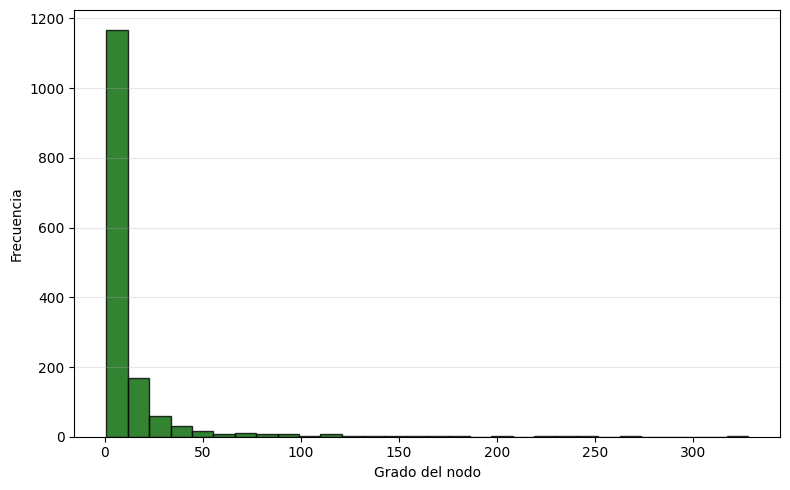

In [ ]:
##Distribución del grado:
grados = [grado for _, grado in G_gigante.degree()]
plt.figure(figsize=(8, 5))
plt.hist(grados, bins=30, edgecolor='black', alpha=0.8, color="darkgreen")
plt.xlabel("Grado del nodo")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Modularidad de la partición: 0.2890


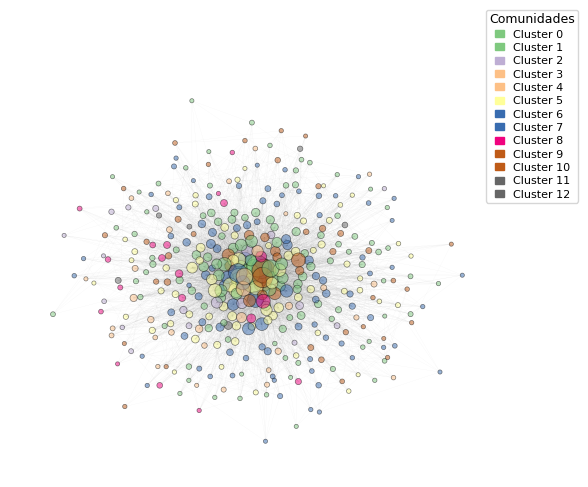


Comunidad 0: ['victima', 'paz', 'violencia', 'mujer', 'participar', 'espacio', 'justicia', 'conflicto', 'especial', 'sexual']

Comunidad 1: ['preguntar', 'fuerza', 'resguardo', 'ambiente', 'restauracion', 'juridico', 'origen', 'belkis', 'jose', 'director']

Comunidad 2: ['seguridad', 'social', 'politico', 'mesa', 'dejar', 'defensa', 'seguimiento', 'militar', 'gente', 'sector']

Comunidad 3: ['acompanamiento', 'tecnico', 'produccion', 'capacitacion', 'material', 'certificacion', 'vegetal', 'obtencion', 'laboral', 'comercializacion']

Comunidad 4: ['ministerio', 'derecho', 'territorial', 'educacion', 'secretario', 'oficina', 'direccion', 'tecnica', 'modelo', 'nacion']

Comunidad 5: ['nacional', 'proteccion', 'accion', 'medida', 'etnico', 'acordar', 'plan', 'frente', 'unidad', 'riesgo']

Comunidad 6: ['comunidad', 'indigena', 'autoridad', 'pueblo', 'organizacion', 'departamento', 'programa', 'poblacion', 'intervencion', 'minuto']

Comunidad 7: ['municipio', 'proyecto', 'atencion', 'desar

In [ ]:
### ----------- Clustering ---------------------

grado_minimo = 10
nodos_importantes = [nodo for nodo, grado in G_gigante.degree() if grado >= grado_minimo]
G_filtrado = G_gigante.subgraph(nodos_importantes)

communities = community_louvain.best_partition(G_gigante, random_state=123)
mod = community_louvain.modularity(communities, G_gigante)
print(f"Modularidad de la partición: {mod:.4f}")
G_comunidades = G_gigante.subgraph(nodos_importantes)
pos = nx.spring_layout(G_comunidades, k=1, iterations=100, seed=25)

plt.figure(figsize=(6, 5))
comunidades_unicas = sorted(set(communities.values()))
n_com = len(comunidades_unicas)
cmap = plt.colormaps["Accent"].resampled(n_com)

color_por_comunidad = {
    com: cmap(i) for i, com in enumerate(comunidades_unicas)}

colores_comunidad = [color_por_comunidad[communities[nodo]]
                     for nodo in G_comunidades.nodes()]
tamaños = [G_gigante.degree(nodo) * 0.9 for nodo in G_comunidades.nodes()]

nx.draw_networkx_nodes(G_comunidades, pos,node_color=colores_comunidad,node_size=tamaños,
    #cmap=plt.cm.Set3,
    alpha=0.5,edgecolors='black',linewidths=0.5)

nx.draw_networkx_edges(G_comunidades, pos,alpha=0.15,width=0.1,edge_color='gray')

leyenda = []
for com in comunidades_unicas:
    parche = mpatches.Patch(color=color_por_comunidad[com], label=f"Cluster {com}")
    leyenda.append(parche)

plt.legend(handles=leyenda, title="Comunidades", loc="center left",bbox_to_anchor=(0.95, 0.9),fontsize=8, title_fontsize=9,
    handlelength=0.8,
    handleheight=0.6,
    labelspacing=0.3,
    borderpad=0.3)
plt.axis('off')
plt.tight_layout()
plt.show()

for comunidad_id in sorted(set(communities.values())):
    nodos_comunidad = [nodo for nodo, com in communities.items() if com == comunidad_id]
    top_nodos = sorted(nodos_comunidad, key=lambda x: G_gigante.degree(x), reverse=True)[:10]
    print(f"\nComunidad {comunidad_id}: {top_nodos}")
